# Explore RSE anomaly scores

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import seaborn as sns

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from anomaly.utils import AnomalyOverlapAnalyzer
from autoencoders.ae import AutoEncoder

from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [3]:
se_cols = [
    'mse',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_97',
    # 'mse_95',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

se_rank_cols = [
    f"rank_{col}" for col in se_cols
]

# ----------------------------------------------
rse_cols = [
    f"{col}_rel" for col in se_cols
]

rse_rank_cols = [
    f"rank_{col}_rel" for col in se_cols
]
# ----------------------------------------------
se_family = [
    'mse',
    'mse_97',
    # 'mse_95',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

rse_family = [
    f'{col}_rel' for col in se_family
]

# Custom functions

## Squared residual

In [4]:
def squared_residual(spec, spec_rec):

    flux_diff = np.abs(spec - spec_rec)
    
    return flux_diff**2

## RSE-iduals

## fine grained

In [5]:
def rse_residual(spec, spec_rec):

    flux_diff_sq = np.abs(spec - spec_rec)**2
    flux_factor = flux_diff_sq / np.abs(spec + 0.001)
    
    return flux_factor

### figure

In [6]:
def fig_RSEidual(
    wave, wave_ticks, wave_lims,
    spec, rec_spec,
    flux_ticks, flux_lims,
    residual,
    res_ticks, res_lims,
    alpha = 0.5,
    figsize=(10, 7)
):

    fig, axs = plt.subplots(
        2, 1,
        sharex=True,
        figsize=figsize
    )
    # ----------------------------------------------------
    axs[0].plot(
        wave, spec,
        color="black", label="Original"
    )
    axs[0].plot(
        wave, rec_spec,
        color="red", alpha=alpha, label="Reconstruction"
    )

    if flux_ticks is False:
        pass
    else:
        axs[0].set_yticks(flux_ticks)
    
    if flux_lims is False:
        pass
    else:
        f_min, f_max = flux_lims
        axs[0].set_ylim(f_min, f_max)
    # ----------------------------------------------------
    # Residulas
    axs[1].plot(
        wave, residual,
        color="black", label="Residuals"
    )

    if res_ticks is False:
        pass
    else:
        axs[1].set_yticks(res_ticks)

    if res_lims is False:
        pass
    else:
        res_min, res_max = res_lims 
        axs[1].set_ylim(res_min, res_max)

    # ----------------------------------------------------
    # labels
    axs[0].legend(
        loc='upper left',
        frameon=False,
        ncol=2
    )
    axs[1].legend(loc='upper left', frameon=False)

    # ----------------------------------------------------

    # wavelengt setup
    if wave_lims is False:
        pass
    else: 
        w_min, w_max = wave_lims
        axs[1].set_xlim(w_min, w_max)

    if wave_ticks is False:
        pass
    else:
        axs[1].set_xticks(wave_ticks)

    # set minor ticks on
    for ax in axs.flatten(): ax.minorticks_on()
    # axe labels
    # x
    axs[1].set_xlabel(r"$\lambda$ [nm]")
    # y
    axs[0].set_ylabel("Flux")
    axs[1].set_ylabel("RES-iduals")

    return fig, axs


# Config

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_id = 'bin_03'
#
ch_4_dir = f"{thesis_dir}/chapters/04_figures"
os.makedirs(f"{ch_4_dir}/{bin_id}", exist_ok=True)

## Data

In [8]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)


In [9]:
emission_lines = list(GALAXY_LINES.keys())

velocity_fil_fn = VelocityFilter(
    wave=wave, velocity_filter=250,
    lines=emission_lines
)

vel_mask = velocity_fil_fn.get_velocity_filter_mask()

## Model

In [10]:
ae_model = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner",
)

## Scores

In [11]:
score_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

rank = np.arange(score_df.shape[0]) + 1
score_rank_df = score_df.copy()
# score_rank_df
for col in score_df.columns:

    index_sorted = score_df.sort_values(
        by=col, ascending=False
    ).index

    score_rank_df.loc[index_sorted, f'rank_{col}'] = rank
    score_rank_df[f'rank_{col}'].astype(int)

In [12]:
score_rank_df[['rank_mse_rel', 'mse_rel']].sort_values(by='mse_rel', ascending=False).head(5)

,rank_mse_rel,mse_rel
specobjid,,
305239577747023872,1.0,24.499810
2830625680629196800,2.0,24.441423
2830685054257096704,3.0,24.168451
734111514142730240,4.0,23.134280
3240467000396376064,5.0,22.655893


# RSE Vs SE

In [39]:
def rse_se_fig(
    spec, rec_spec, 
    wave_nm, 
    rseidual, squared_res,
    rse_rank, se_rank, 
    figsize=(20, 7), alpha=0.5
):

    fig, axs = plt.subplots(
        2, 2,
        sharex=True,
        figsize=figsize
    )
    # ----------------------------------------------------
    # 
    axs[0, 0].plot(
        wave_nm, spec,
        color="black", label="Original"
    )

    axs[0, 0].plot(
        wave_nm, rec_spec,
        alpha=alpha,
        color="red", label="Reconstruction"
    )

    # flux_ticks = [0, 10, 20, 30, 40]
    # axs[0, 0].set_yticks(flux_ticks)
    # axs[0, 0].set_ylim(0, 40)

    # ----------------------------------------------------
    #
    axs[0, 1].plot(
        wave_nm, spec,
        color="black", label="Original"
    )
    axs[0, 1].plot(
        wave_nm, rec_spec,
        color="red", alpha=alpha, label="Reconstruction"
    )

    # flux_ticks = [0, 10, 20, 30, 40]
    # axs[0, 1].set_yticks(flux_ticks)
    # axs[0, 1].set_ylim(0, 40)
    # ----------------------------------------------------
    # Residulas
    # RSE
    axs[1, 0].plot(
        wave_nm, rseidual,
        color="black", label="Residuals"
    )
    # res_ticks = [0, 5, 10, 15, 20, 25]
    # axs[1, 0].set_yticks(res_ticks)
    # axs[1, 0].set_ylim(0, 26)

    axs[1, 0].text(
        0.95, 0.95,
        f"RSE Rank: {rse_rank:.0f}",
        horizontalalignment="right", verticalalignment="center",
        transform=axs[1, 0].transAxes,
        fontsize=12
    )

    # SE
    axs[1, 1].plot(
        wave_nm, squared_res,
        color="black", label="Residuals"
    )

    # res_ticks = [0, 10, 20, 30, 40]
    # axs[1, 1].set_yticks(res_ticks)
    # axs[1, 1].set_ylim(0, 42)

    axs[1, 1].text(
        0.95, 0.95,
        f"SE Rank: {se_rank:.0f}",
        horizontalalignment="right", verticalalignment="center",
        transform=axs[1, 1].transAxes,
        fontsize=12
    )
    # ----------------------------------------------------
    # labels
    axs[0, 0].legend(
        loc='upper left',
        frameon=False,
        # fontsize=10,
        ncol=2
    )
    axs[0, 1].legend(
        loc='upper left',
        frameon=False,
        # fontsize=10,
        ncol=2
    )

    # ----------------------------------------------------

    # wavelengt setup
    axs[1, 0].set_xlim(350, 770)
    axs[1, 1].set_xlim(350, 770)
    # # wave_ticks = [370]
    wave_ticks = list(np.arange(350, 751, 50))
    axs[1, 0].set_xticks(wave_ticks)
    axs[1, 1].set_xticks(wave_ticks)
    # set minor ticks on
    for ax in axs.flatten(): ax.minorticks_on()

    # ax labels
    axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
    axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
    axs[0, 0].set_ylabel("Flux")
    axs[1, 0].set_ylabel(r"R$^2$")

    # adjust vertical space
    plt.subplots_adjust(
        hspace=0.03, 
        wspace=0.07
    )
    return fig, axs

In [15]:
rse_candidates = [
    7, 11, 15, 20, 21, 27, 47,
    72, # artifact rank 1 in mse
    856, 911
]

rank_mse_rel    911.0
rank_mse        425.0
Name: 1882639117586556928, dtype: float64

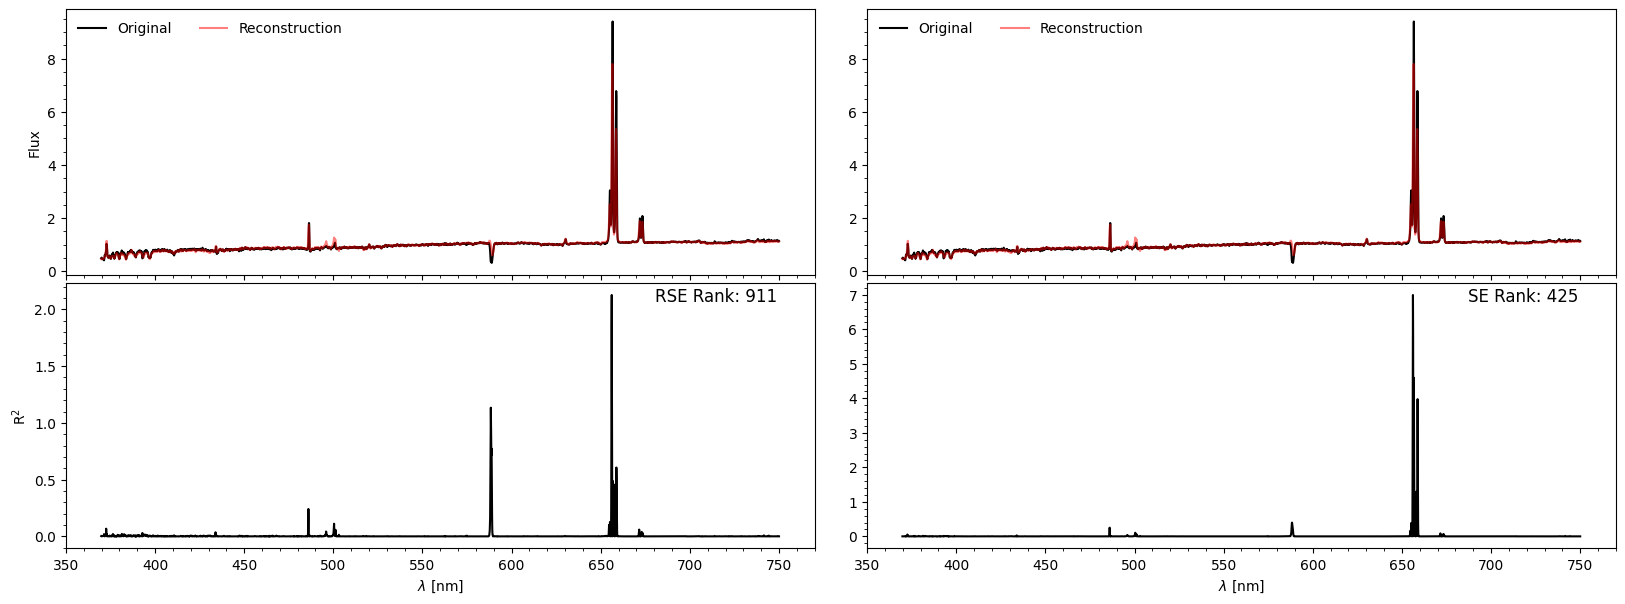

In [43]:
mask = score_rank_df.rank_mse_rel == 911
specid = score_rank_df.loc[mask].index.values[0]
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RSEidual = rse_residual(spec, rec_spec)
squared_res = squared_residual(spec, rec_spec)
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    RSEidual, squared_res,
    rse_rank, se_rank,
    alpha=0.5
)

# -------------------------------------------------------
score_rank_df.loc[specid, ['rank_mse_rel', 'rank_mse']].T

# Filter RES

In [ ]:
filter_rse_candidates = [
    1,
    4, # exp blue slope with flux below 1
    9, # blue slope but no flux below 1
    34, # very interesting: bumpy with a dip
    80, # similar to 34
    890, # unique to this score
]

rank_mse_filter_250_rel     1323.0
rank_mse_filter_250        19896.0
Name: 319786117589133312, dtype: float64

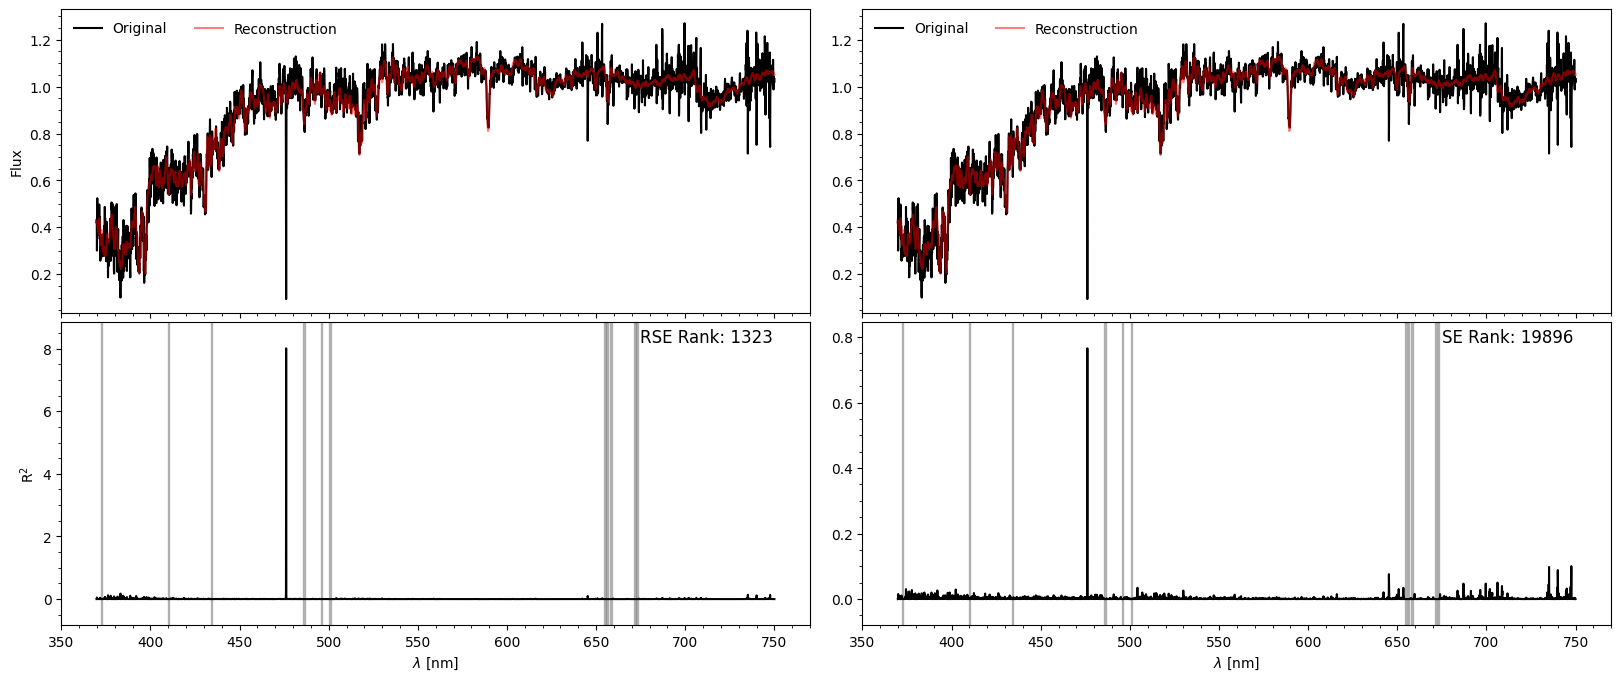

In [83]:
mask = score_rank_df.rank_mse_filter_250_rel == 1323
specid = score_rank_df.loc[mask].index.values[0]
# specid = 2032375840699869184
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
# ------------------------------------------------------
RSEidual = rse_residual(spec, rec_spec)
rseidual_vel_maked = rse_residual(spec, rec_spec)*vel_mask
# ------------------------------------------------------
squared_res = squared_residual(spec, rec_spec)
squared_res_vel_maked = squared_residual(spec, rec_spec)*vel_mask
# 
rse_rank = score_rank_df.loc[specid, 'rank_mse_filter_250_rel']
se_rank = score_rank_df.loc[specid, 'rank_mse_filter_250']
# -------------------------------------------------------
fig, axs = rse_se_fig(
    spec, rec_spec, wave_nm,
    rseidual_vel_maked, squared_res_vel_maked,
    rse_rank, se_rank,
    figsize=(20, 8),
    alpha=0.5
)
# ----------------------------------------------------
# shaded regions
axs[1, 0].fill_between(
    wave_nm, 
    0, 1,              # Fill from bottom (0) to top (1) of the axis
    where=~vel_mask,    # Only where your mask is True
    color='gray',      # Color of the shade
    alpha=0.5,         # Transparency
    transform=axs[1, 0].get_xaxis_transform(), # Key: maps y to axis fractions
    label='Masked lines'
)
axs[1, 1].fill_between(
    wave_nm, 
    0, 1,              # Fill from bottom (0) to top (1) of the axis
    where=~vel_mask,    # Only where your mask is True
    color='gray',      # Color of the shade
    alpha=0.5,         # Transparency
    transform=axs[1, 1].get_xaxis_transform(), # Key: maps y to axis fractions
    label='Masked lines'
)
# # leggends
# axs[1, 0].legend(loc='upper right', frameon=False, fontsize=10)
# axs[1, 1].legend(loc='upper right', frameon=False, fontsize=10)

# -------------------------------------------------------
# w_min, w_max = (480,510)
# w_min, w_max = (650, 680)
# axs[1, 0].set_xlim(w_min, w_max)
# axs[1, 1].set_xlim(w_min, w_max)
# -------------------------------------------------------

score_rank_df.loc[specid, ['rank_mse_filter_250_rel', 'rank_mse_filter_250']].T

In [21]:
# mask = score_rank_df.rank_mse_filter_250_rel == 890
# specid = score_rank_df.loc[mask].index.values[0]
# # specid = int(specid)
# idx_spec = specobjid_to_idx(specid, idx_id_spec)
# spec = spectra[idx_spec]
# rec_spec = ae_model.reconstruct(spec)[0]
# RESidual = rse_residual(spec, rec_spec)
# # -------------------------------------------------------
# # figure
# fig, axs = fig_RSEidual(
#     wave=wave_nm,
#     wave_ticks=False,
#     wave_lims=(350, 750),
#     # wave_lims=(600, 700),
#     spec=spec, rec_spec=rec_spec,
#     flux_ticks=False, flux_lims=False,
#     residual=RESidual,
#     res_ticks=False, res_lims=False,
#     alpha = 0.5,
#     figsize=(10, 7)
# )
# # -------------------------------------------------------
# score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T

# Trim RSE

## Rank 666

rank_mse_rel                   2649.0
rank_mse_filter_250_rel        2750.0
rank_mse_97_rel                 666.0
rank_mse_filter_250_97_rel     4092.0
rank_mse                      55746.0
rank_mse_filter_250           48354.0
rank_mse_97                   29058.0
rank_mse_filter_250_97        63173.0
Name: 1781231151415846912, dtype: float64

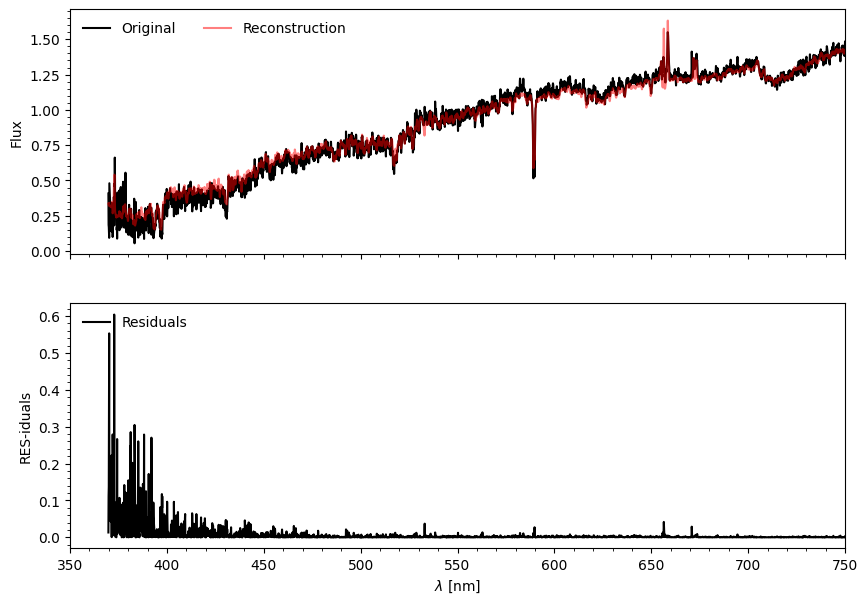

In [ ]:
mask = score_rank_df.rank_mse_97_rel == 666
specid = score_rank_df.loc[mask].index.values[0]
# specid = int(specid)
idx_spec = specobjid_to_idx(specid, idx_id_spec)
spec = spectra[idx_spec]
rec_spec = ae_model.reconstruct(spec)[0]
RESidual = rse_residual(spec, rec_spec)
# -------------------------------------------------------
# figure
fig, axs = fig_RSEidual(
    wave=wave_nm,
    wave_ticks=False,
    wave_lims=(350, 750),
    # wave_lims=(600, 700),
    spec=spec, rec_spec=rec_spec,
    flux_ticks=False, flux_lims=False,
    residual=RESidual,
    res_ticks=False, res_lims=False,
    alpha = 0.5,
    figsize=(10, 7)
)
# -------------------------------------------------------
score_rank_df.loc[specid, rse_rank_cols + se_rank_cols].T